In [2]:
import pandas as pd

df = pd.read_csv("fordgobike-tripdataFor201902.csv")

df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [3]:
df.shape

(183416, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [5]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='str')

In [6]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [10]:
df['duration_sec'].mean() / 60

np.float64(12.101121857780493)

In [11]:
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [18]:
df['member_birth_year'] = df['member_birth_year'].fillna(df['member_birth_year'].median())

station_cols = ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name']
for col in station_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['member_gender'] = df['member_gender'].fillna('Other')

df.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

In [21]:
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')
df['age'] = (2019 - df['member_birth_year']).astype(int)
df['duration_min'] = df['duration_sec'] / 60
df['duration_hour'] = df['duration_sec'] / 3600

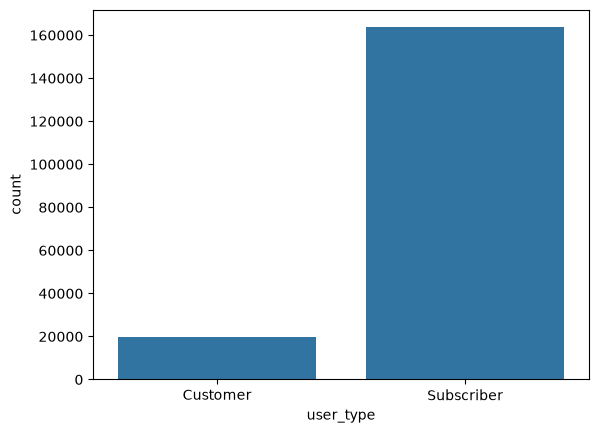

In [22]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.countplot(data=df, x='user_type')
plt.show()

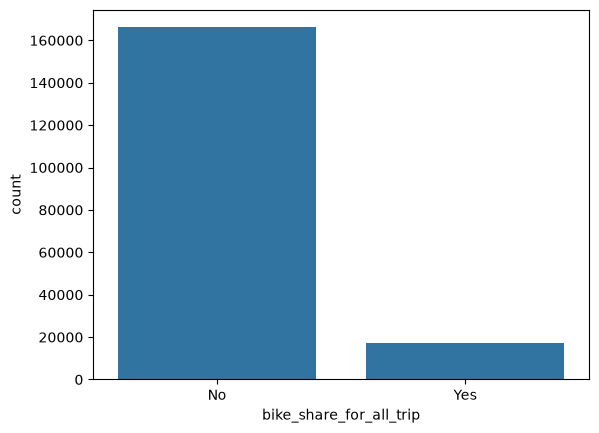

In [23]:
sb.countplot(data=df, x='bike_share_for_all_trip')
plt.show()

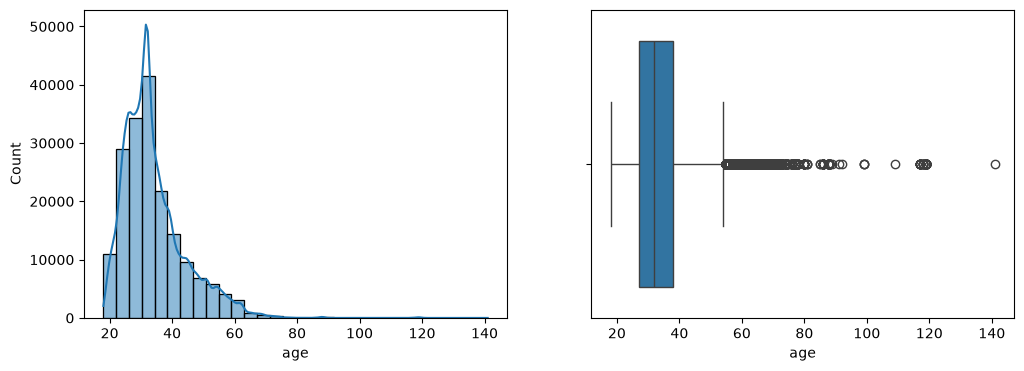

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sb.histplot(df['age'], bins=30, kde=True)
plt.subplot(1, 2, 2)
sb.boxplot(x=df['age'])
plt.show()

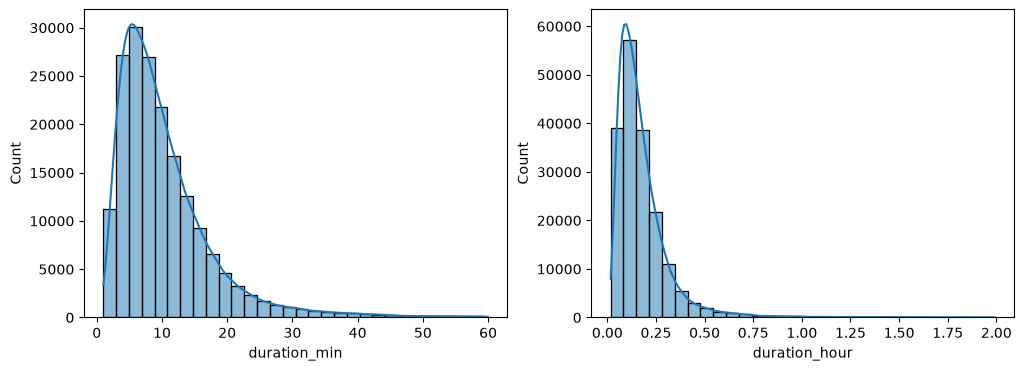

In [25]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sb.histplot(df[df['duration_min'] <= 60]['duration_min'], bins=30, kde=True)
plt.subplot(1, 2, 2)
sb.histplot(df[df['duration_hour'] <= 2]['duration_hour'], bins=30, kde=True)
plt.show()

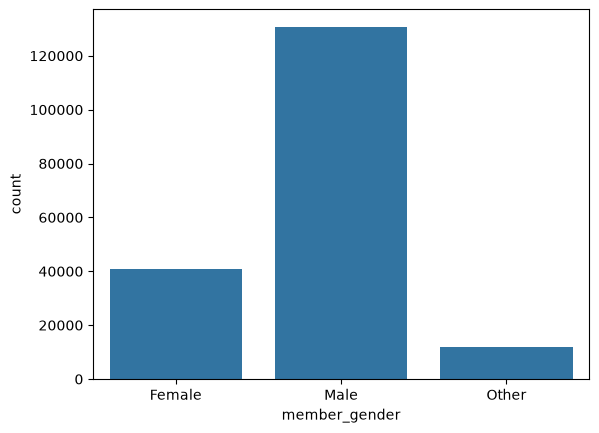

In [26]:
sb.countplot(data=df, x='member_gender')
plt.show()

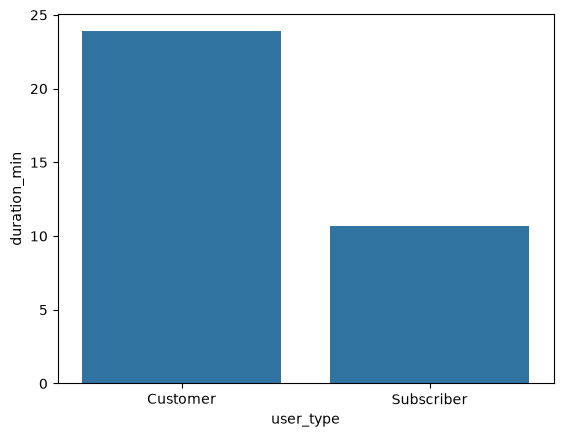

In [27]:
sb.barplot(data=df, x='user_type', y='duration_min', errorbar=None)
plt.show()

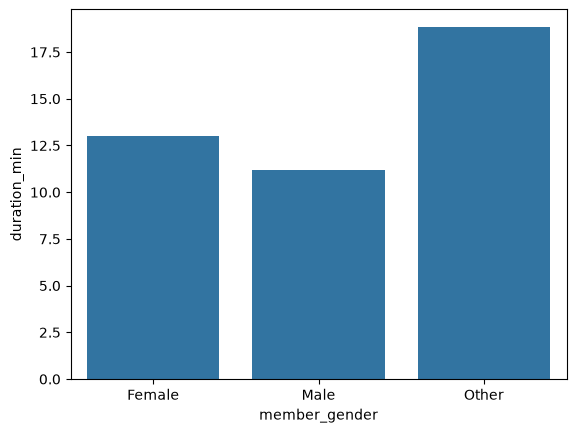

In [28]:
sb.barplot(data=df, x='member_gender', y='duration_min', errorbar=None)
plt.show()

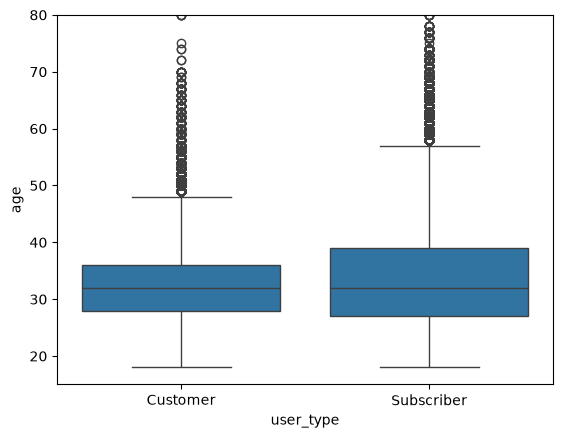

In [29]:
sb.boxplot(data=df, x='user_type', y='age')
plt.ylim(15, 80)
plt.show()

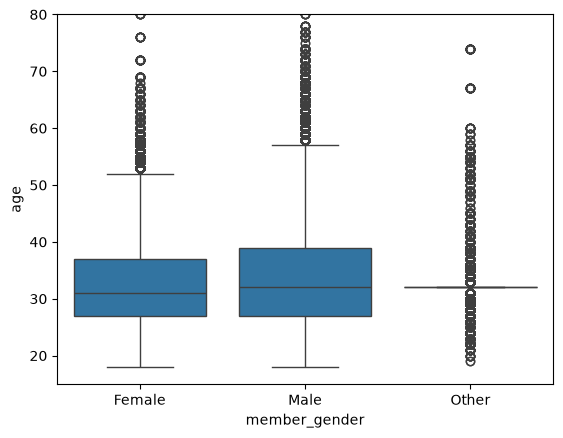

In [30]:
sb.boxplot(data=df, x='member_gender', y='age')
plt.ylim(15, 80)
plt.show()

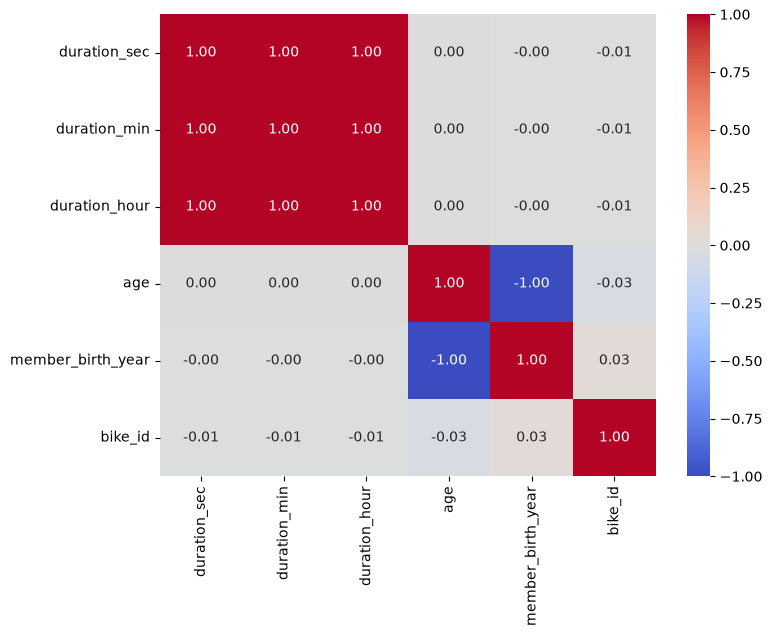

In [31]:
plt.figure(figsize=(8, 6))
numeric_cols = ['duration_sec', 'duration_min', 'duration_hour', 'age', 'member_birth_year', 'bike_id']
sb.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()